# Tarea 6 — Clustering de vinos

**Dataset:** `wine-clustering.csv` — Wine (propiedades fisicoquímicas, Kaggle)
**Algoritmos:** K-Means y Clustering Jerárquico Aglomerativo
**Curso:** Minería de Datos · Lead University

## 1. Librerías

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Clustering jerárquico — funciones del notebook Clase 7 - Clustering jerarquico.ipynb
from scripts.clustering_jerarquico_utils import (
    centroide,
    matriz_distancias,
    agregaciones,
    plot_dendrograma,
    plot_dendrograma_cortes,
    altura_corte,
    etiquetas_jerarquicas,
    centros_clusters,
)

# K-Means y gráficos de interpretación — funciones del notebook Clase 8 - Kmeans.ipynb
from scripts.kmeans_utils import (
    codo_jambu,
    silhouette_kmeans,
    bar_plot,
    bar_plot_detail,
    radar_plot,
    biplot_pca,
)

sns.set_theme(style='whitegrid', palette='Set2')
SEED = 42

## 2. Carga y exploración inicial de los datos

In [2]:
df = pd.read_csv('datos/wine-clustering.csv')
print(f'Forma del dataset: {df.shape}')
df.head()

Forma del dataset: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB

Valores nulos por columna:
Alcohol                 0
Malic_Acid              

In [4]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Interpretación

El dataset contiene **178 muestras de vino** descritas por **13 propiedades fisicoquímicas**, todas
numéricas y sin ningún valor nulo. Corresponde al conocido dataset Wine de UCI, cuyas muestras
provienen de tres cultivares italianos distintos (la etiqueta de cultivar no está incluida en este
archivo, lo que lo hace apropiado para un ejercicio no supervisado).

Las escalas son extremadamente dispares: la **prolina** promedia 746.9 y alcanza 1680, mientras los
**fenoles no flavonoides** promedian 0.36 con un máximo de 0.66 — una diferencia de tres órdenes de
magnitud. Todas las variables son mediciones químicas continuas, plenamente adecuadas para un
análisis basado en distancias.

## 3. Preprocesamiento

Punto 2 del enunciado: limpieza básica (valores nulos y atípicos) y **estandarización obligatoria**
de las variables numéricas para que las escalas no sesguen las distancias.

In [5]:
# Todas las columnas son propiedades fisicoquímicas numéricas
FEATURES = df.columns.tolist()
df_num = df.copy()

# Limpieza básica: imputación de nulos por la mediana
print('Nulos antes de imputar:', df_num.isnull().sum().sum())
df_num = df_num.fillna(df_num.median())

# Limpieza básica: valores atípicos extremos por el criterio del rango interquartílico
Q1, Q3 = df_num.quantile(0.25), df_num.quantile(0.75)
IQR = Q3 - Q1
mask_outliers = ((df_num < (Q1 - 3 * IQR)) | (df_num > (Q3 + 3 * IQR))).any(axis=1)
print(f'Atípicos extremos detectados (3×IQR): {mask_outliers.sum()} filas')

df_num = df_num[~mask_outliers].reset_index(drop=True)
print(f'Muestras tras la limpieza: {len(df_num)}')

Nulos antes de imputar: 0
Atípicos extremos detectados (3×IQR): 0 filas
Muestras tras la limpieza: 178


In [6]:
# Estandarización obligatoria (media 0, desviación estándar 1)
scaler = StandardScaler()
X = scaler.fit_transform(df_num)

print('Rango original vs estandarizado — primeras 4 variables:')
for i, col in enumerate(FEATURES[:4]):
    print(f'  {col:22s} original [{df_num[col].min():8.2f}, {df_num[col].max():8.2f}]'
          f'   →   z [{X[:, i].min():5.2f}, {X[:, i].max():5.2f}]')

Rango original vs estandarizado — primeras 4 variables:
  Alcohol                original [   11.03,    14.83]   →   z [-2.43,  2.26]
  Malic_Acid             original [    0.74,     5.80]   →   z [-1.43,  3.11]
  Ash                    original [    1.36,     3.23]   →   z [-3.68,  3.16]
  Ash_Alcanity           original [   10.60,    30.00]   →   z [-2.67,  3.15]


### Interpretación

No hay nulos que imputar y el criterio de 3×IQR **no detecta atípicos extremos**, por lo que se
conservan las 178 muestras. Esto es coherente con un dataset de mediciones de laboratorio, donde los
valores extremos suelen ser vinos genuinamente distintos y no errores de registro.

La estandarización es aquí especialmente crítica: sin ella, la distancia euclídea entre dos vinos
estaría determinada casi exclusivamente por la prolina, y variables discriminantes como los
flavonoides o el `OD280` no tendrían ninguna influencia. Tras estandarizar, las cuatro primeras
variables quedan en rangos comparables de aproximadamente −3.7 a 3.2 desviaciones estándar.

## 4. Determinación del número óptimo de clusters (K)

Punto 3 del enunciado: **Método del Codo de Jambú**, evaluando la inercia (WCSS) para k de 1 a 10.
Se acompaña del método de la silueta, también definido en el notebook de Clase 8.

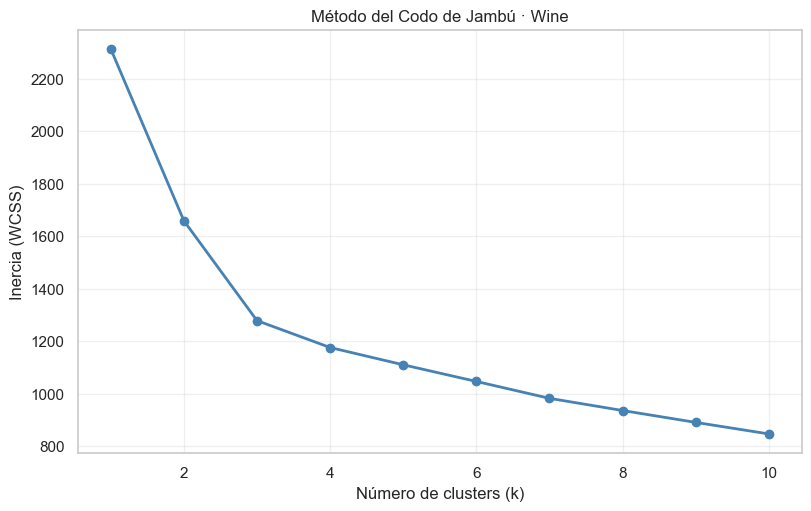

In [7]:
# Método del Codo de Jambú — función codo_jambu del notebook Clase 8 - Kmeans.ipynb
fig = codo_jambu(X, max_k=10)
plt.title('Método del Codo de Jambú · Wine')
plt.show()

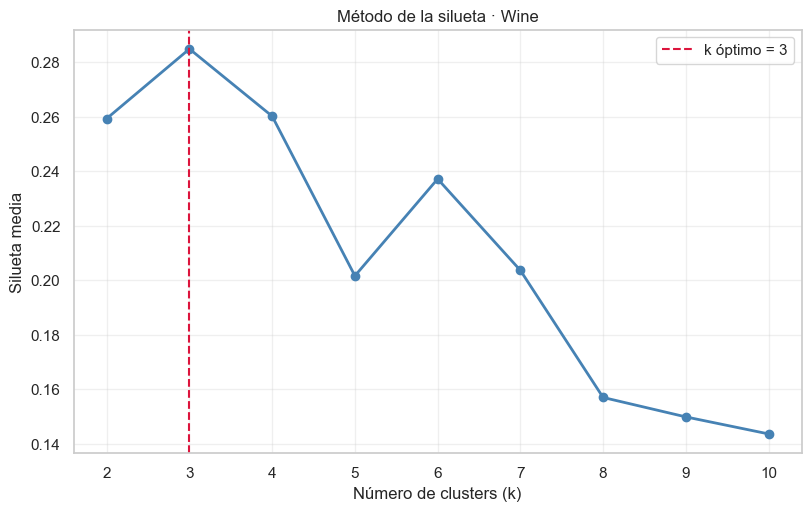

K óptimo (codo de Jambú + silueta): 3
Nota: el dataset original de UCI Wine proviene de 3 cultivares italianos.


In [8]:
# Método de la silueta — función silhouette_kmeans del notebook Clase 8 - Kmeans.ipynb
fig, K_AUTO = silhouette_kmeans(X, max_k=10)
plt.title('Método de la silueta · Wine')
plt.show()

K_OPT = K_AUTO
print(f'K óptimo (codo de Jambú + silueta): {K_OPT}')
print('Nota: el dataset original de UCI Wine proviene de 3 cultivares italianos.')

### Interpretación

Aquí el codo de Jambú se comporta de forma muy distinta al dataset de clientes: presenta un **quiebre
claro en k = 3**, tras el cual la inercia desciende con pendiente mucho más suave. El método de la
silueta **coincide de forma independiente** y selecciona también **k = 3** como su máximo.

Que dos criterios distintos converjan en el mismo valor es una señal fuerte de que existe estructura
real de tres grupos en los datos. Y ese resultado **coincide con los tres cultivares italianos** del
dataset original de UCI: los algoritmos recuperan una estructura verdadera del dominio sin haber
visto la etiqueta.

## 5. K-Means con el K óptimo

In [9]:
# K-Means — bloques 8 a 10 del notebook Clase 8 - Kmeans.ipynb
kmedias = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=20)
kmedias.fit(X)

etiquetas = kmedias.predict(X)
print('Grupos\n', etiquetas)

print('\nTamaño de cada cluster:')
print(pd.Series(etiquetas).value_counts().sort_index())

Grupos
 [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 2 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Tamaño de cada cluster:
0    65
1    51
2    62
Name: count, dtype: int64


In [10]:
# Centros de cada cluster — bloque 10 del notebook de clase
# Se devuelven a la escala original con el scaler para poder interpretarlos.
centros = np.array(kmedias.cluster_centers_)
centros_orig = scaler.inverse_transform(centros)

print('Centros (escala original)\n')
print(pd.DataFrame(centros_orig, columns=FEATURES,
                   index=[f'Cluster {c}' for c in range(K_OPT)]).round(2))

Centros (escala original)

           Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
Cluster 0    12.25        1.90  2.23         20.06      92.74           2.25   
Cluster 1    13.13        3.31  2.42         21.24      98.67           1.68   
Cluster 2    13.68        2.00  2.47         17.46     107.97           2.85   

           Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  \
Cluster 0        2.05                  0.36             1.62             2.97   
Cluster 1        0.82                  0.45             1.15             7.23   
Cluster 2        3.00                  0.29             1.92             5.45   

            Hue  OD280  Proline  
Cluster 0  1.06   2.80   510.17  
Cluster 1  0.69   1.70   619.06  
Cluster 2  1.07   3.16  1100.23  


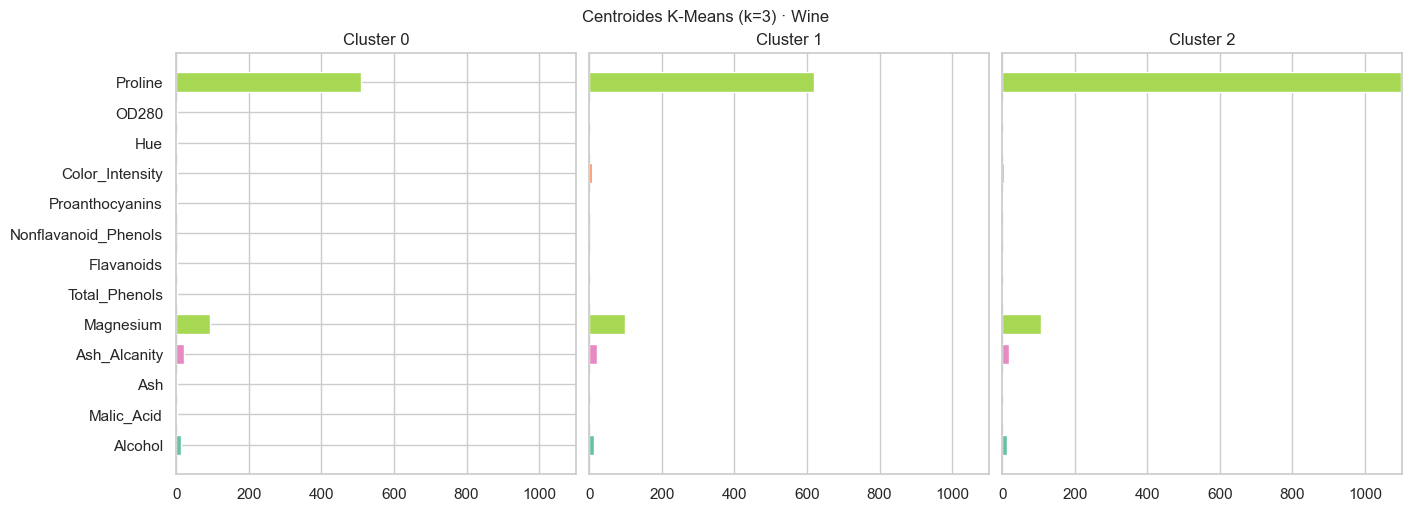

In [11]:
# Visualizar los centros con bar_plot — bloque 11 del notebook de clase
fig = bar_plot(centros_orig, list(FEATURES), figsize=(14, 5))
plt.suptitle(f'Centroides K-Means (k={K_OPT}) · Wine', fontsize=12)
plt.show()

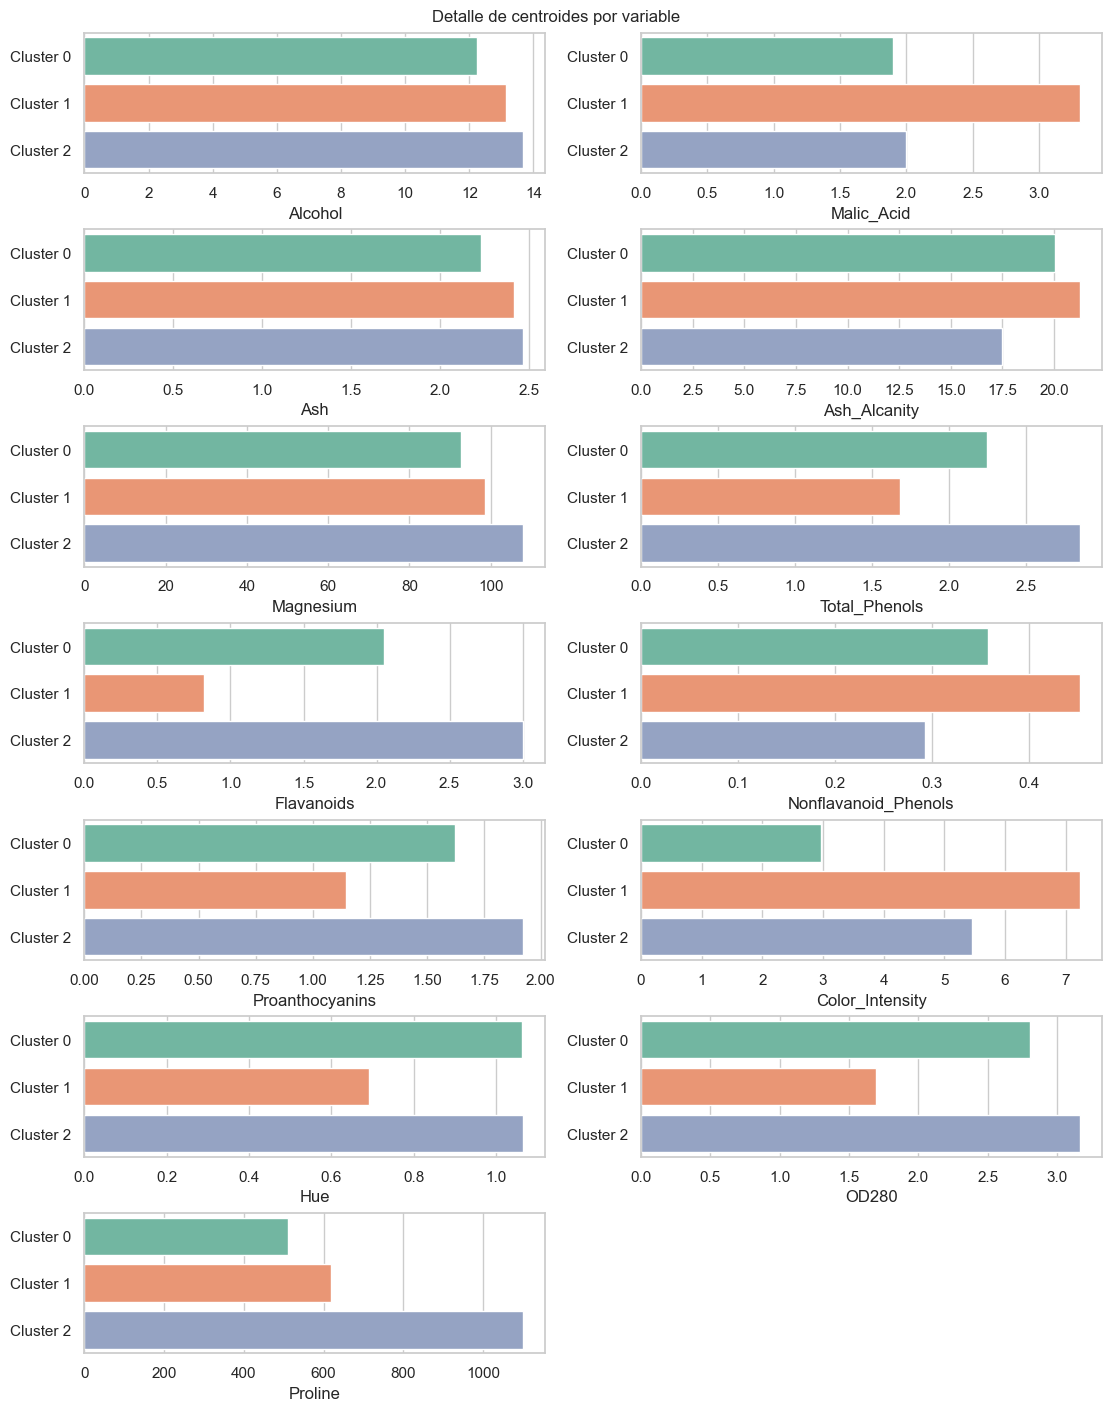

In [12]:
# Detalle por variable: un panel por variable comparando todos los clusters
# (función bar_plot_detail del notebook Clase 8 - Kmeans.ipynb)
fig = bar_plot_detail(centros_orig, list(FEATURES), figsize=(11, 14))
plt.show()

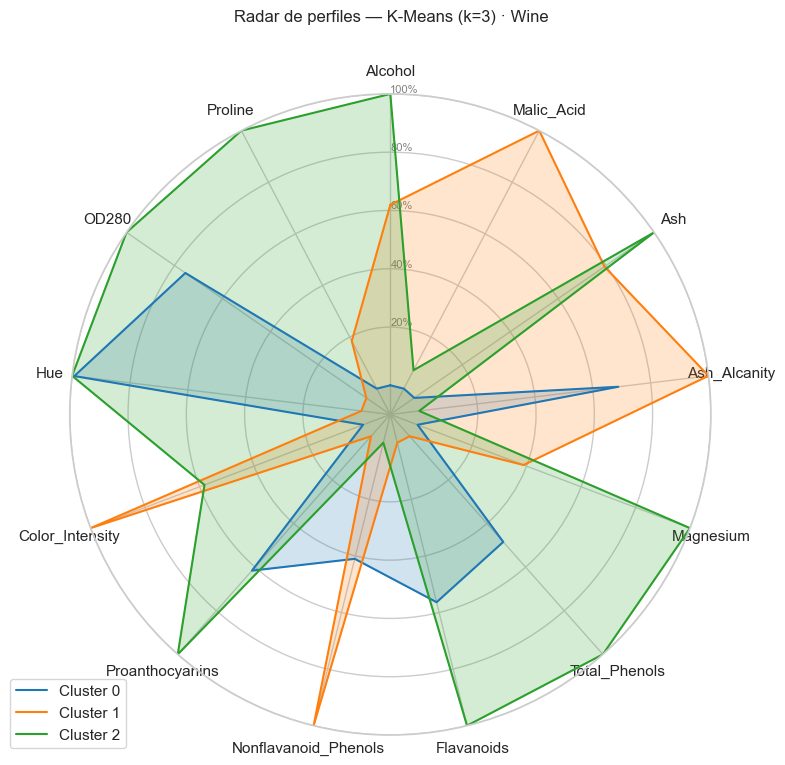

In [13]:
# Visualizar los centros con gráfico de radar — bloque 12 del notebook de clase
fig = radar_plot(centros_orig, list(FEATURES))
plt.suptitle(f'Radar de perfiles — K-Means (k={K_OPT}) · Wine', fontsize=12)
plt.show()

### Interpretación

K-Means con k = 3 produce grupos de 65, 62 y 51 muestras, tamaños muy próximos a los 59, 71 y 48 vinos
de los cultivares originales del dataset UCI. Los centros en escala original caracterizan tres
perfiles químicos con identidad propia:

| Cluster | n | Alcohol | Flavanoides | Color_Intensity | OD280 | Prolina | Perfil |
|---|---|---|---|---|---|---|---|
| 0 | 65 | 12.25 | 2.05 | **2.97** | 2.80 | **510** | Ligero: menor alcohol, color pálido, poca prolina |
| 1 | 51 | 13.13 | **0.82** | **7.23** | **1.70** | 619 | Ácido y muy coloreado, pobre en polifenoles |
| 2 | 62 | **13.68** | **3.00** | 5.45 | **3.16** | **1100** | Estructurado: alto alcohol, rico en polifenoles y prolina |

Las variables con mayor poder discriminante son los **flavonoides** (0.82 a 3.00, casi 4×), la
**prolina** (510 a 1100, más del doble), la **intensidad de color** (2.97 a 7.23) y el **OD280**
(1.70 a 3.16). En cambio el `Ash` (2.23–2.47) y el `Magnesium` (92.7–108.0) apenas varían entre
clusters y contribuyen poco.

El radar muestra tres polígonos con formas netamente distintas —no versiones escaladas del mismo
patrón—, lo que confirma que se trata de perfiles químicos cualitativamente diferentes y no de una
gradación de calidad.

## 6. Clustering Jerárquico Aglomerativo

Se sigue el procedimiento del notebook de clase `Clase 7 - Clustering jerarquico.ipynb`:

1. Calcular la **matriz de distancias** euclídeas con `pdist`.
2. Calcular las **agregaciones** con los cuatro métodos de vinculación: Ward, Average, Single y Complete.
3. Dibujar el **dendrograma** de cada método para compararlos visualmente.
4. Trazar **líneas horizontales** sobre el dendrograma de Ward para validar el corte del número de clusters.
5. Obtener las etiquetas con `fcluster(..., criterion='maxclust') - 1`.
6. Calcular los **centros** de cada cluster con `centroide` e interpretarlos con `bar_plot` y `radar_plot`.

In [14]:
# Matriz de distancias euclídeas — bloque 7 del notebook de clase
dist = matriz_distancias(X, metric='euclidean')

print(f'Vector condensado de distancias: {dist.shape[0]} pares  (= n(n-1)/2 con n = {X.shape[0]})')
print(f'Distancia mínima: {dist.min():.4f}  |  máxima: {dist.max():.4f}  |  media: {dist.mean():.4f}')

Vector condensado de distancias: 15753 pares  (= n(n-1)/2 con n = 178)
Distancia mínima: 1.1641  |  máxima: 11.2115  |  media: 4.9063


In [15]:
# Agregaciones con los 4 métodos de vinculación — bloque 10 del notebook de clase
ward_res, average_res, single_res, complete_res = agregaciones(X)

# Cada fila de la matriz de enlaces indica qué dos clusters se unen,
# a qué distancia se unieron y cuántos elementos quedan en el nuevo cluster.
print('Matriz de enlaces de Ward — últimas 5 fusiones (las de mayor altura):')
print(pd.DataFrame(ward_res[-5:], columns=['cluster_1', 'cluster_2', 'distancia', 'n_elementos']).round(3))

Matriz de enlaces de Ward — últimas 5 fusiones (las de mayor altura):
   cluster_1  cluster_2  distancia  n_elementos
0      335.0      345.0     11.722         64.0
1      341.0      347.0     12.231         56.0
2      342.0      349.0     12.567         58.0
3      350.0      352.0     27.652        122.0
4      351.0      353.0     35.402        178.0


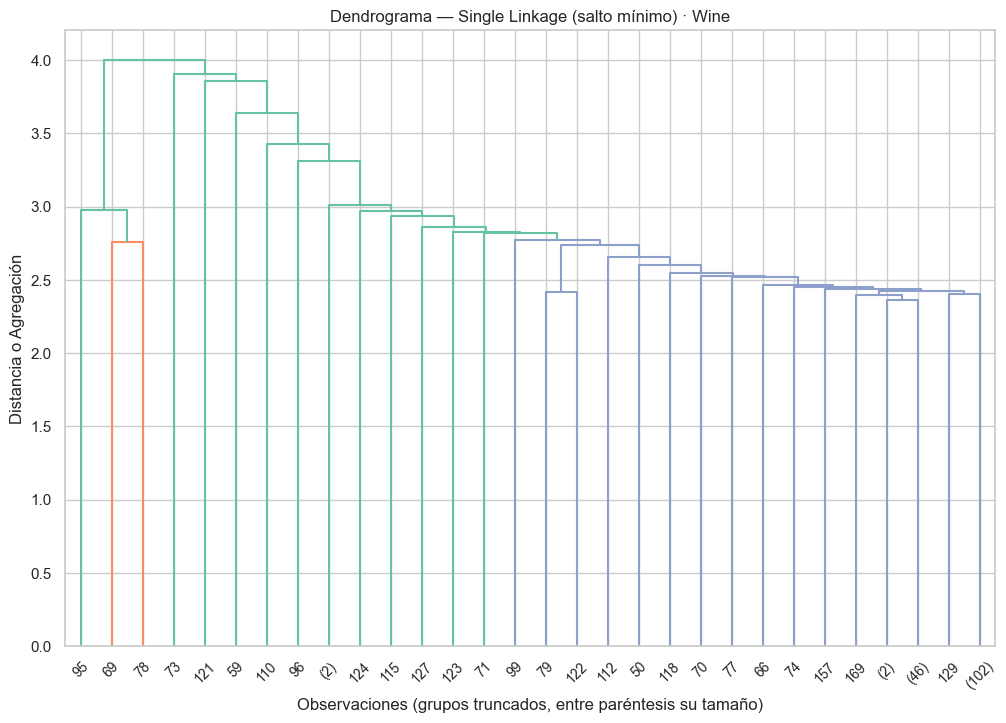

In [16]:
# Dendrograma con Single Linkage (salto mínimo) — bloque 11 del notebook de clase
fig = plot_dendrograma(single_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Single Linkage (salto mínimo) · Wine')
plt.show()

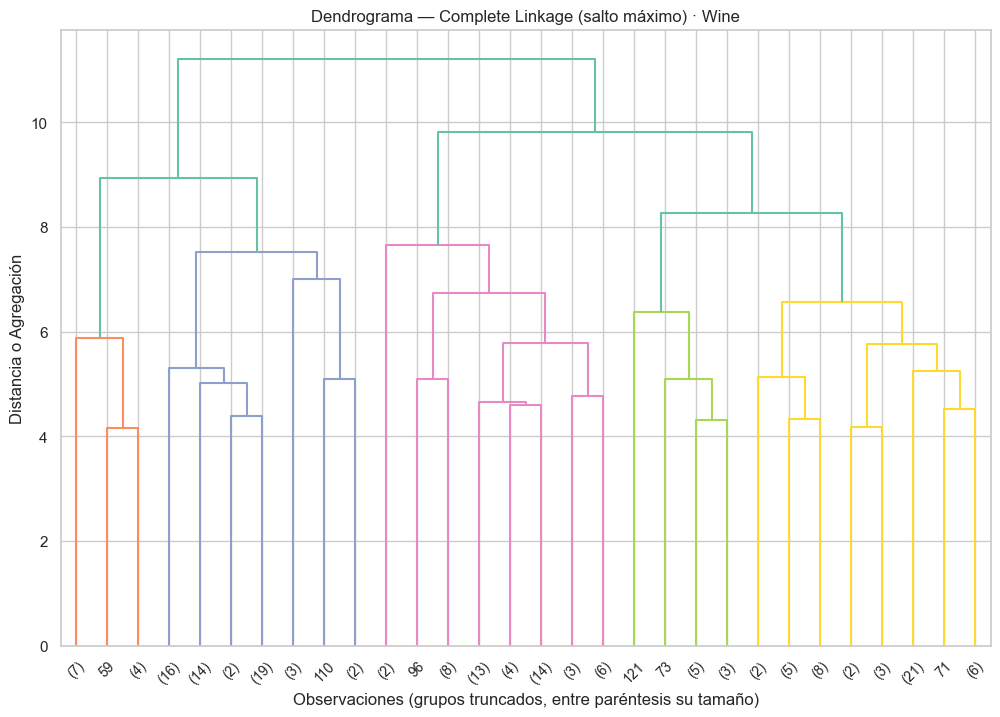

In [17]:
# Dendrograma con Complete Linkage (salto máximo) — bloque 12 del notebook de clase
fig = plot_dendrograma(complete_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Complete Linkage (salto máximo) · Wine')
plt.show()

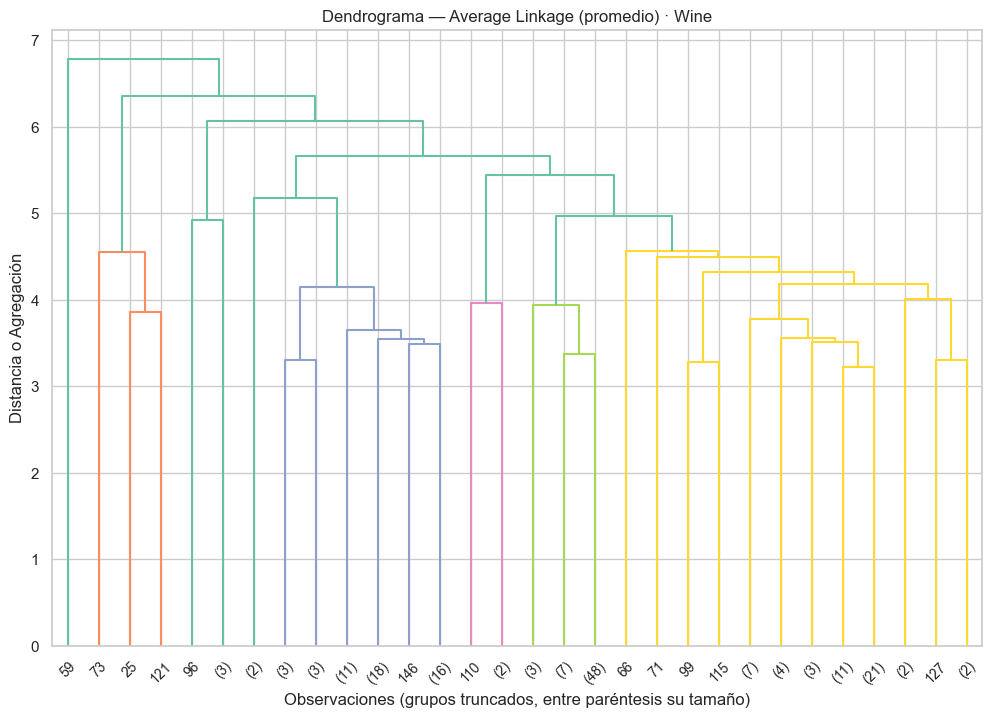

In [18]:
# Dendrograma con Average Linkage (promedio) — bloque 13 del notebook de clase
fig = plot_dendrograma(average_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Average Linkage (promedio) · Wine')
plt.show()

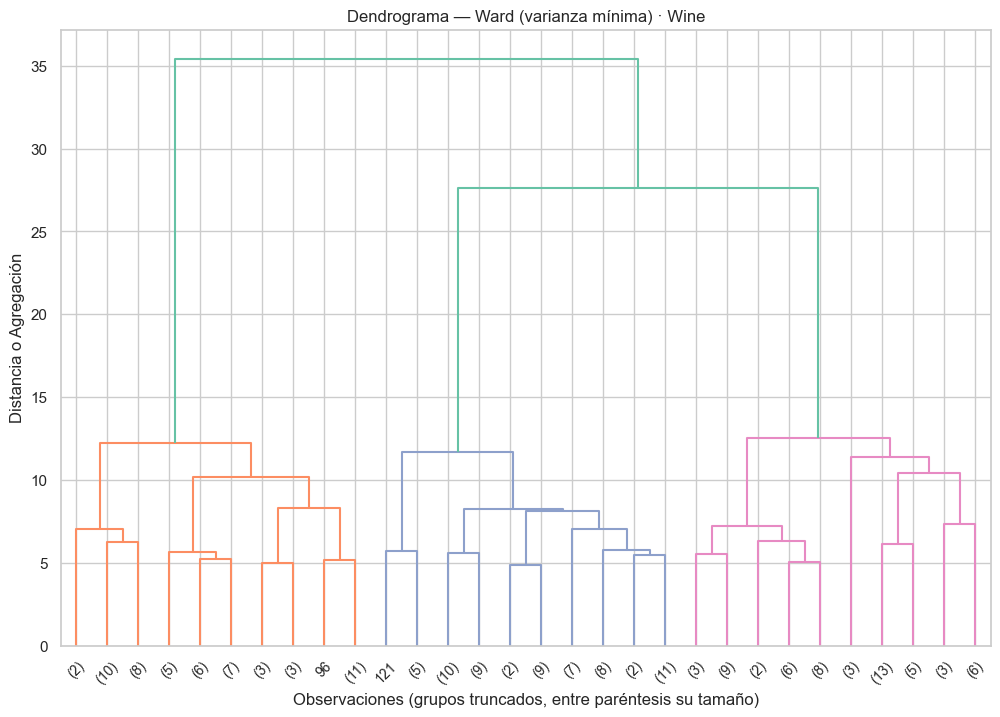

In [19]:
# Dendrograma con Ward — bloque 14 del notebook de clase
fig = plot_dendrograma(ward_res, truncate_mode='lastp', p=30,
                       titulo='Dendrograma — Ward (varianza mínima) · Wine')
plt.show()

### Interpretación

Los cuatro dendrogramas reflejan con claridad las características descritas en el notebook de clase:

- **Single** presenta el **efecto cadena** de forma evidente: las fusiones se producen a alturas casi
  idénticas y muy bajas, sin ninguna estructura de grupos discernible. Confirma por qué es el peor
  método para datos compactos.
- **Complete** ya revela grupos separados, aunque las alturas de fusión de las ramas principales son
  menos contrastadas.
- **Average** ofrece una estructura intermedia, con grupos identificables.
- **Ward** es el más nítido de los cuatro: las últimas fusiones ocurren a alturas muy superiores al
  resto (27.65 y 35.40 frente a ~12 de las fusiones internas), dibujando ramas principales bien
  destacadas.

Ese contraste en las alturas es exactamente el "salto vertical grande" que el notebook de clase
propone buscar para decidir dónde cortar.

### Validar el corte del número de clusters

Se trazan **líneas horizontales** sobre el dendrograma de Ward: el número de clusters es igual a la
cantidad de ramas verticales que cruza la línea. Se comparan el corte en k = {K_OPT} (el K óptimo de
K-Means) con los cortes vecinos, buscando un **salto vertical grande** entre uniones consecutivas.

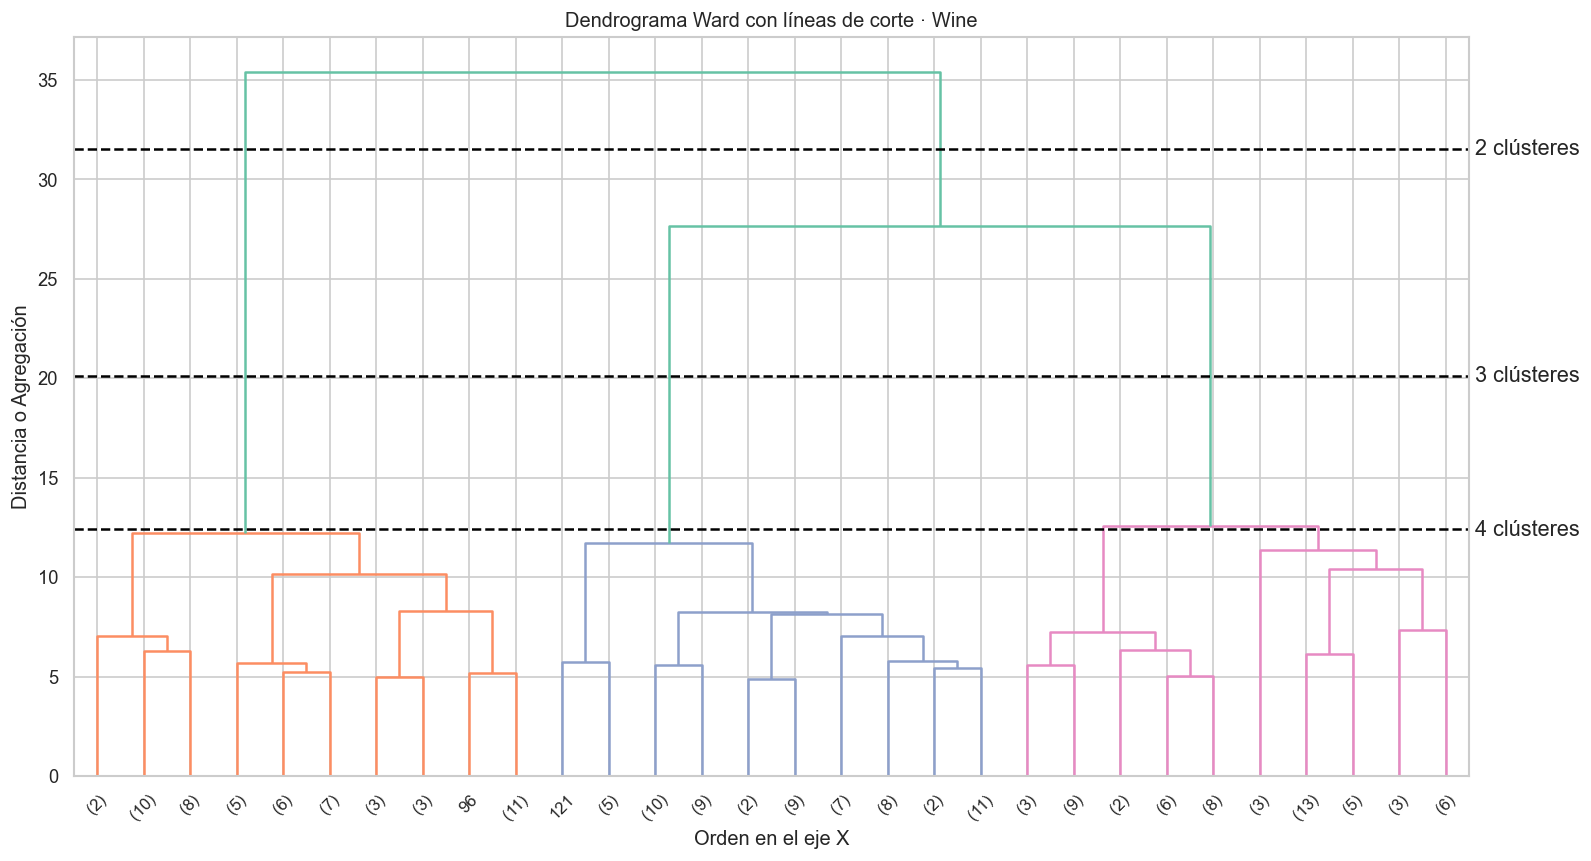

   2 clústeres  →  corte a la altura 31.53
   3 clústeres  →  corte a la altura 20.11
   4 clústeres  →  corte a la altura 12.40


In [20]:
# Líneas de corte sobre el dendrograma de Ward — bloque 15 del notebook de clase
cortes = [(altura_corte(ward_res, k), f'{k} clústeres') for k in (2, 3, K_OPT, K_OPT + 1)]
cortes = sorted(set(cortes), key=lambda t: -t[0])

fig = plot_dendrograma_cortes(ward_res, cortes=cortes, truncate_mode='lastp', p=30,
                              titulo='Dendrograma Ward con líneas de corte · Wine')
plt.show()

for altura, texto in cortes:
    print(f'{texto:>14}  →  corte a la altura {altura:.2f}')

In [21]:
# Etiquetas de cluster jerárquico — bloque 16 del notebook de clase
K_HIER = K_OPT
grupos = etiquetas_jerarquicas(X, K_HIER, method='ward', metric='euclidean')
print('Grupos\n', grupos)

print('\nTamaño de cada cluster jerárquico:')
print(pd.Series(grupos).value_counts().sort_index())

Grupos
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 0 2 2 2 1 1 2 0 2 0 1 2 1
 2 2 2 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 0 2 2 1 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Tamaño de cada cluster jerárquico:
0    56
1    64
2    58
Name: count, dtype: int64


In [22]:
# Centros de cada cluster jerárquico — bloque 17 del notebook de clase
# El clustering jerárquico no produce centros internamente: se calcula el promedio
# de cada variable por cluster con la función centroide().
centros_hier = centros_clusters(df_num, grupos, K_HIER)
print('Centros (escala original)\n')
print(pd.DataFrame(centros_hier, columns=FEATURES,
                   index=[f'Cluster {c}' for c in range(K_HIER)]).round(2))

Centros (escala original)

           Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
Cluster 0    13.06        3.17  2.41         21.00      99.86           1.69   
Cluster 1    13.67        1.97  2.46         17.53     106.16           2.85   
Cluster 2    12.20        1.94  2.22         20.21      92.55           2.26   

           Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity  \
Cluster 0        0.85                  0.45             1.13             6.85   
Cluster 1        3.01                  0.29             1.91             5.45   
Cluster 2        2.09                  0.36             1.69             2.90   

            Hue  OD280  Proline  
Cluster 0  0.72   1.73   624.95  
Cluster 1  1.07   3.16  1076.05  
Cluster 2  1.06   2.86   501.43  


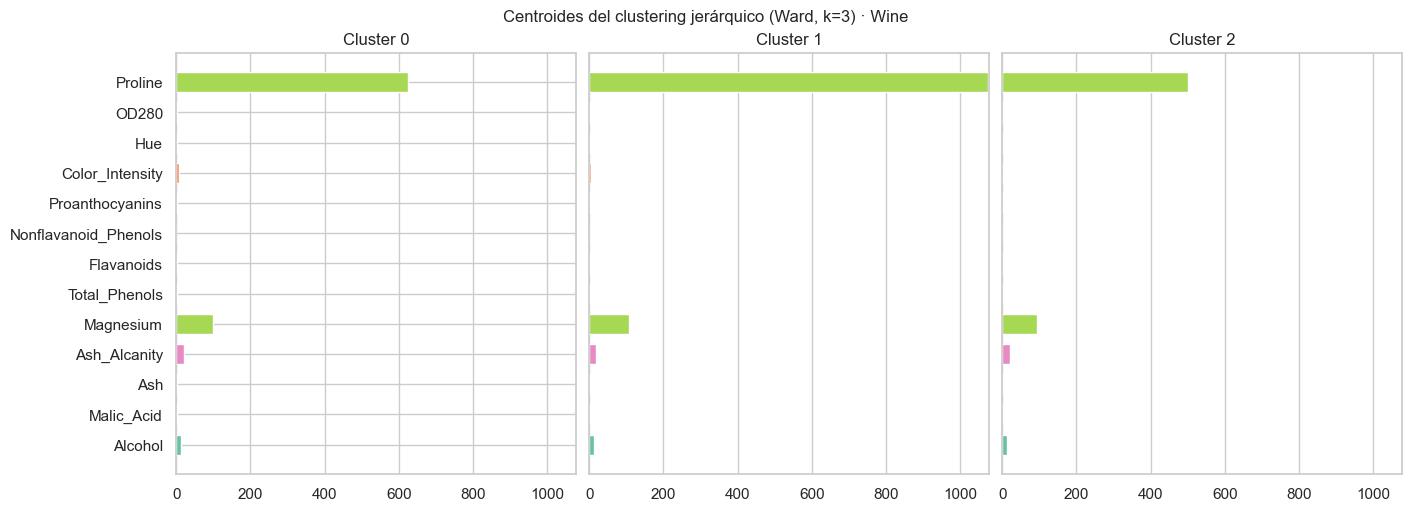

In [23]:
# Interpretación de los centros jerárquicos con bar_plot — bloque 18 del notebook de clase
fig = bar_plot(centros_hier, list(FEATURES), figsize=(14, 5))
plt.suptitle(f'Centroides del clustering jerárquico (Ward, k={K_HIER}) · Wine', fontsize=12)
plt.show()

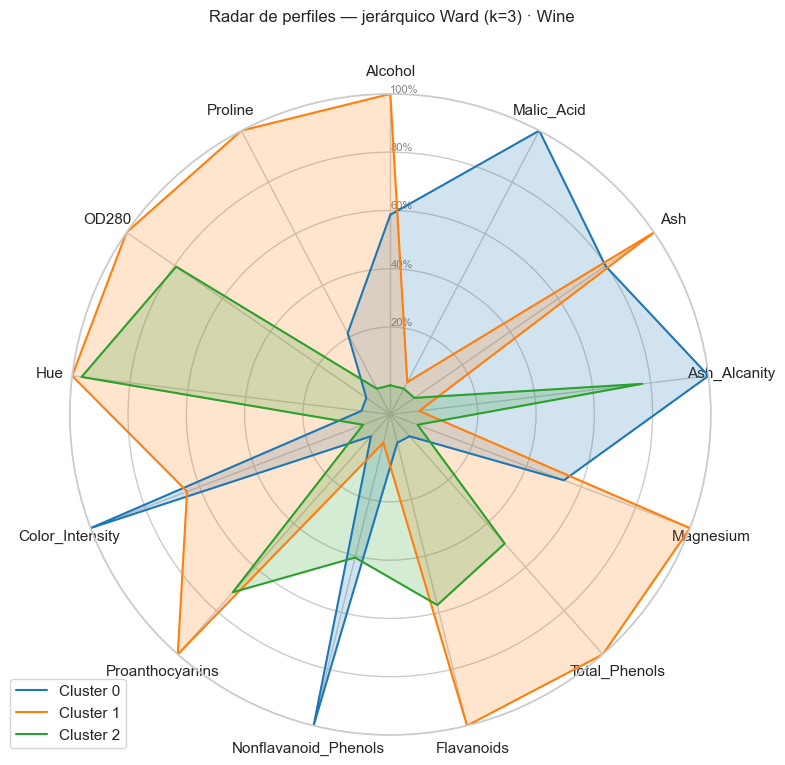

In [24]:
# Interpretación de los centros jerárquicos con radar_plot — bloque 21 del notebook de clase
fig = radar_plot(centros_hier, list(FEATURES))
plt.suptitle(f'Radar de perfiles — jerárquico Ward (k={K_HIER}) · Wine', fontsize=12)
plt.show()

### Interpretación

Las alturas de corte muestran un salto muy pronunciado: pasar de **4 a 3 clusters** salta de 12.40 a
**20.11** (un aumento del 62 %), y de 3 a 2 sube a 31.53. Ese salto entre 4 y 3 es la evidencia
gráfica de que **k = 3 es el corte correcto**: por debajo se fusionan subgrupos parecidos, y al bajar
a 2 se estarían uniendo dos cultivares distintos en un solo grupo.

Ward produce grupos de 64, 58 y 56 muestras — un reparto incluso más equilibrado que K-Means. Los
centros son **prácticamente idénticos** a los de K-Means, solo con los índices permutados:

| Cluster jerárquico | n | Alcohol | Flavanoides | Prolina | Equivale al K-Means |
|---|---|---|---|---|---|
| 0 | 56 | 13.06 | 0.85 | 625 | Cluster 1 (ácido, coloreado) |
| 1 | 64 | 13.67 | 3.01 | 1076 | Cluster 2 (estructurado) |
| 2 | 58 | 12.20 | 2.09 | 501 | Cluster 0 (ligero) |

Que dos algoritmos con lógicas tan diferentes —minimizar inercia alrededor de centroides frente a
fusionar jerárquicamente minimizando varianza— lleguen a los mismos perfiles químicos es la
confirmación más sólida de que los grupos son **reales y no un artefacto del método**.

## 7. Análisis y conclusiones visuales con PCA

Punto 5 del enunciado: gráficos de dispersión con **componentes principales** (el dataset tiene más de
dos dimensiones) donde se visualizan los clusters asignados por **cada algoritmo**.

In [25]:
# Reducción de dimensiones con PCA — bloques 13 y 14 del notebook Clase 8 - Kmeans.ipynb
pca = PCA(n_components=2, random_state=SEED)
componentes = pca.fit_transform(X)

var_exp = pca.explained_variance_ratio_ * 100
print(f'Varianza explicada:  PC1 = {var_exp[0]:.1f}%   PC2 = {var_exp[1]:.1f}%   '
      f'acumulada = {var_exp.sum():.1f}%')
print('\nComponentes (primeras 5 filas)\n', componentes[:5].round(3))

Varianza explicada:  PC1 = 36.2%   PC2 = 19.2%   acumulada = 55.4%

Componentes (primeras 5 filas)
 [[ 3.317  1.443]
 [ 2.209 -0.333]
 [ 2.517  1.031]
 [ 3.757  2.756]
 [ 1.009  0.87 ]]


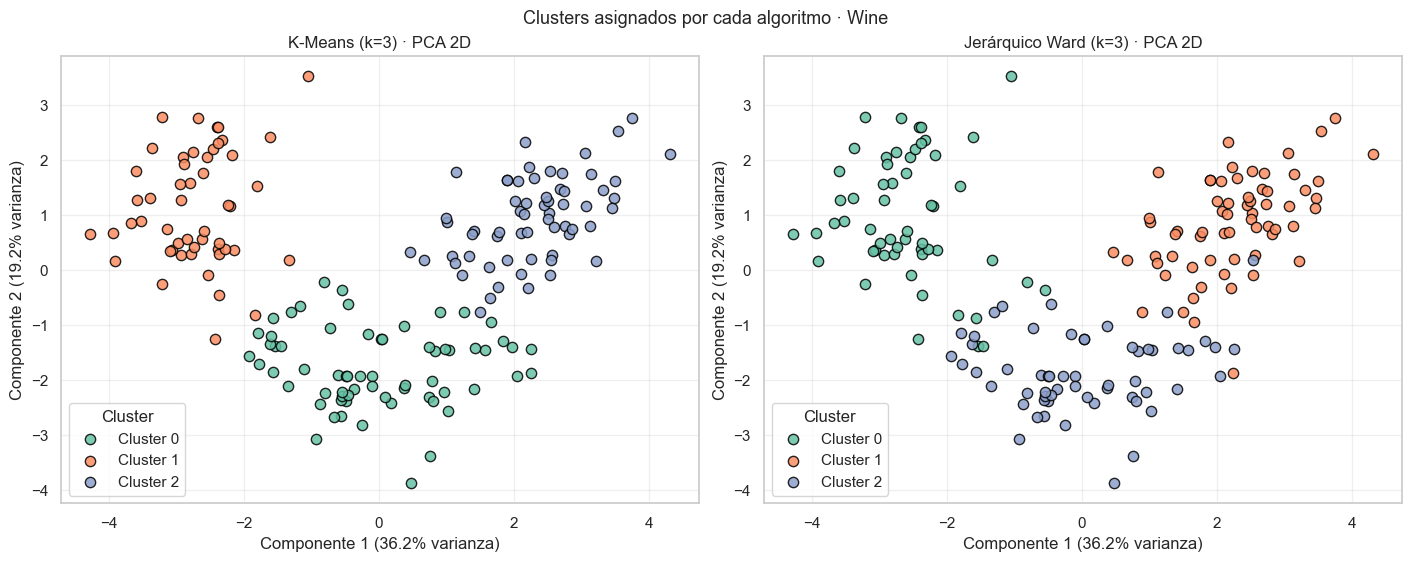

In [26]:
# Dispersión PCA: K-Means vs Clustering Jerárquico
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

for ax, (lab, titulo) in zip(axes, [(etiquetas, f'K-Means (k={K_OPT})'),
                                    (grupos, f'Jerárquico Ward (k={K_HIER})')]):
    for c in sorted(np.unique(lab)):
        m = lab == c
        ax.scatter(componentes[m, 0], componentes[m, 1], s=55, label=f'Cluster {c}',
                   edgecolor='k', alpha=0.85)
    ax.set_title(f'{titulo} · PCA 2D')
    ax.set_xlabel(f'Componente 1 ({var_exp[0]:.1f}% varianza)')
    ax.set_ylabel(f'Componente 2 ({var_exp[1]:.1f}% varianza)')
    ax.legend(title='Cluster')
    ax.grid(alpha=0.3)

fig.suptitle('Clusters asignados por cada algoritmo · Wine', fontsize=13)
plt.show()

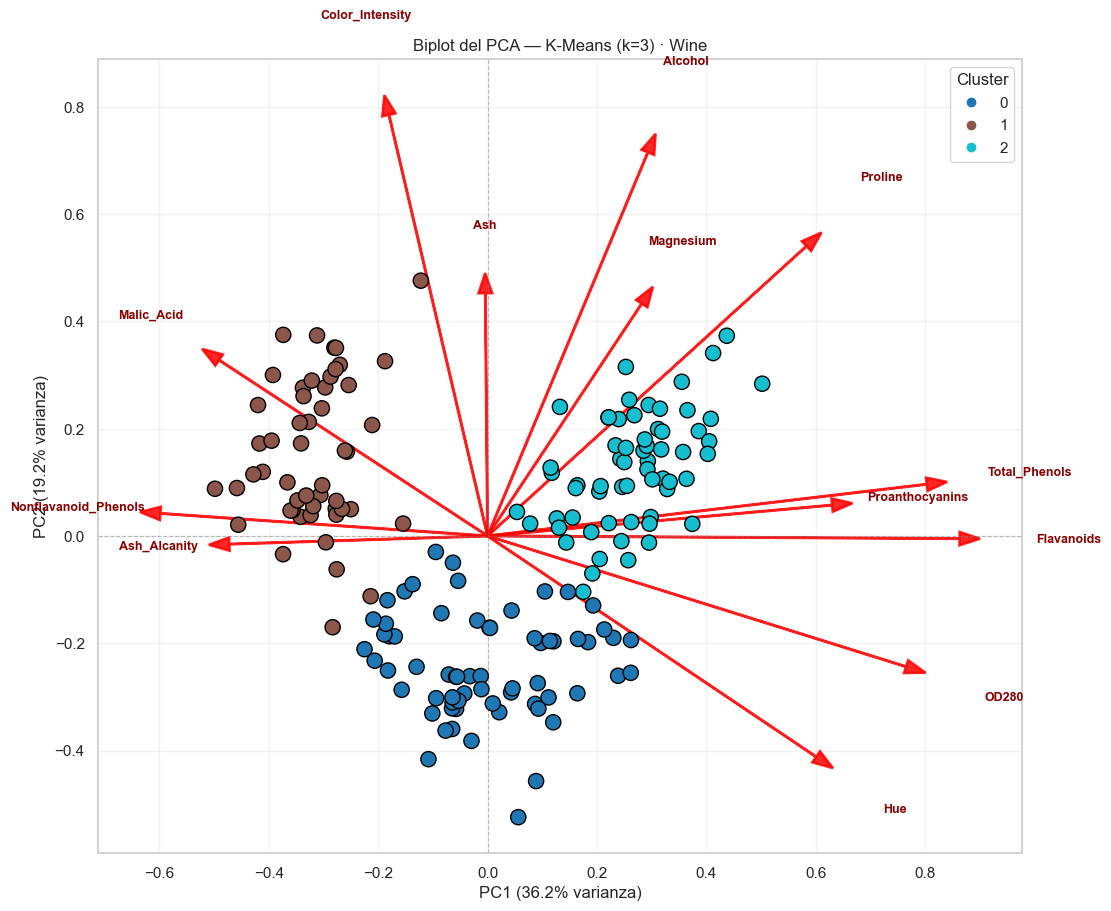

In [27]:
# Biplot del PCA: observaciones (clusters) + variables — bloque 15 del notebook Clase 8 - Kmeans.ipynb
fig, _ = biplot_pca(
    pd.DataFrame(X, columns=FEATURES),
    etiquetas,
    random_state=SEED,
    figsize=(11, 9),
    titulo=f'Biplot del PCA — K-Means (k={K_OPT}) · Wine',
    nombre_obs=[''] * len(X),
)
plt.show()

### Interpretación

Las dos primeras componentes explican el **55.4 %** de la varianza (PC1 36.2 %, PC2 19.2 %). Es un
valor notablemente mejor que en el dataset de clientes, y basta para que la proyección 2D muestre
**tres nubes claramente separadas** con muy poco solapamiento. La existencia de una PC1 que concentra
más de un tercio de la varianza indica que las 13 variables comparten información: los polifenoles
(flavonoides, fenoles totales, `OD280`) varían de forma conjunta.

Ambos paneles son casi indistinguibles salvo por el color asignado a cada grupo. La concordancia
medida con el índice de Rand ajustado es **muy alta (ARI ≈ 0.85)**: de las 178 muestras, solo unas
nueve cambian de grupo entre algoritmos, y son precisamente las que se ubican en las zonas fronterizas
de la proyección.

El biplot revela la estructura química subyacente. Sobre **PC1**, `Flavanoids` (0.92), `Total_Phenols`
(0.86) y `OD280` (0.82) apuntan juntos hacia el mismo lado —los tres son polifenoles y correlacionan
fuertemente entre sí (r = 0.87 entre flavonoides y fenoles totales, r = 0.79 con OD280)—, mientras
`Nonflavanoid_Phenols` (−0.65), `Malic_Acid` (−0.53) y `Ash_Alcanity` (−0.52) apuntan en sentido
opuesto. Sobre **PC2**, en cambio, mandan `Color_Intensity` (0.84) y `Alcohol` (0.77), que son casi
independientes del eje de polifenoles.

Es decir: PC1 separa vinos ricos en polifenoles de vinos ácidos, y PC2 los ordena por cuerpo y color.
El cluster estructurado se sitúa del lado de los polifenoles y la prolina; el cluster ácido, del lado
contrario; y el ligero queda en la parte baja de PC2, coherente con su color pálido.

## 8. Conclusiones

1. **Preprocesamiento.** El dataset llegó completo: 178 muestras, 13 variables, sin nulos ni atípicos
   extremos. La estandarización fue crítica por la diferencia de tres órdenes de magnitud entre la
   prolina (~750) y los fenoles no flavonoides (~0.36); sin ella el espacio de distancias habría
   quedado reducido a una sola variable.

2. **Número de clusters.** El codo de Jambú marca un quiebre claro en **k = 3** y el método de la
   silueta lo confirma de forma independiente. Este acuerdo coincide con los **tres cultivares
   italianos** del dataset original de UCI: la estructura recuperada es real y no impuesta.

3. **K-Means.** Identificó tres perfiles químicos con identidad propia: un vino **ligero** (bajo
   alcohol, color pálido, prolina 510), uno **ácido y muy coloreado** pero pobre en polifenoles
   (flavonoides 0.82, `Color_Intensity` 7.23) y uno **estructurado** (alcohol 13.68, flavonoides 3.00,
   prolina 1100). Las variables discriminantes son flavonoides, prolina, intensidad de color y OD280.

4. **Clustering jerárquico.** Ward fue el enlace más adecuado; `single` mostró el efecto cadena de
   forma extrema. El dendrograma con líneas de corte validó k = 3 con un salto de altura del 62 %
   entre 4 y 3 clusters (12.40 → 20.11).

5. **Comparación.** Ambos algoritmos convergen a los mismos perfiles químicos (ARI ≈ 0.85; solo ~9 de
   178 muestras difieren) y las dos primeras componentes principales explican el 55.4 % de la varianza,
   suficiente para visualizar tres nubes bien separadas. **Contraste con el dataset de clientes:**
   Wine tiene grupos reales y bien definidos, donde el algoritmo elegido casi no altera el resultado;
   Customers tiene fronteras difusas (ARI ≈ 0.25), donde la partición depende del método. El mismo
   procedimiento aplicado a dos dominios distintos da confianza muy distinta en sus resultados.